## Telco Customer Churn Analysis

- This notebook predicts customer churn using Logistic Regression and Random Forest models. 
- It includes data inspection, preprocessing, visualization, scaling, training, evaluation, and inline explanations.
------------------------------------

## Database Overview
The database contains 7044 rows(customers) and 21 columns (feautres).

**Features:**

- customerID: Unique identifier of a customer
- gender: Gender of customer
- SeniorCitizen: Binary variable indicating if customer is senior citizen 
- Partner: Binary variable if customer has a partner
- Dependents: Binary variable if customer has dependent
- tenure: Number of weeks as a customer
- PhoneService: Whether customer has phone service
- MultipleLines: Whether customer has multiple lines
- InternetService: What type of internet service customer has ("DSL", "Fiber optic", "No")
- OnlineSecurity: Whether customer has online security service
- OnlineBackup: Whether customer has online backup service
- DeviceProtection: Whether customer has device protection service 
- TechSupport: Whether customer has tech support service
- StreamingTV: Whether customer has TV streaming service
- StreamingMovies: Whether customer has movies streaming service
-  Contract: Customer Contract Type ('Month-to-month', 'One year', 'Two year')
- PaperlessBilling: Whether paperless billing is enabled
- PaymentMethod: Payment method
- MonthlyCharges: Amount of monthly charges in $
- TotalCharges: Amount of total charges so far
- Churn: Whether customer 'Stayed' or 'Churned'.

--------------------------------------------------------------------------
## Import Libraries

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

# Ensure plots appear inline
%matplotlib inline

---------------------------------------------
## Load The Telco-Customer-Churn Data 

In [2]:
# Load the dataset
data = pd.read_csv('Telco-Customer-Churn.csv')

# Display the first few rows of the dataset
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


--------------------------------------------------------
## Data Inspection

- Display the first 10 rows of the dataset
- Output the names of the dataset's columns
- Display the data types of each column. 

In [3]:
# Display the first 10 rows of the dataset
print("First 10 rows of the dataset:\n", data.head(10))

First 10 rows of the dataset:
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone 

In [4]:
# Display the names of the dataset's columns
print("Column names in the dataset:")
data.columns.tolist()

Column names in the dataset:


['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [5]:
# Display the data types of each column
print("Data types of each column:") 
data.dtypes

Data types of each column:


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

------------------------------------------------------------
## Data Preprocessing

- Convert the “TotalCharges” column to the numeric data type.
- Remove rows with missing values from the dataset.
- Remove the “customerID” column from the dataset.
- Convert the "Churn” column to binary numeric values: replace “Yes” with 1 and “No” with 0.
- Convert all categorical variables in the dataset into dummy variables. Store the result in a new DataFrame called telecom_cust_dummies.

In [6]:
# Convert TotalCharges to numeric
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Remove rows with missing values
data.dropna(inplace=True)

# Remove the customerID column
data.drop('customerID', axis=1, inplace=True)

# Convert the Churn column to binary numeric values
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

# Convert categorical variables into dummy variables
# Used `drop_first=True` to avoid dummy variable trap.
telecom_cust_dummies = pd.get_dummies(data, drop_first=True)

# Display the first few rows to verify
print(telecom_cust_dummies.head())

print("Data successfully loaded and preprocessed.")

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...                            Fa

----------------------------------------------------------------
## Data Visualisation

- Create a correlation plot to visualise the correlation between features and the target variable “Churn”.
- Create a histogram of the “tenure” column.
- Create a scatter plot of “MonthlyCharges” vs. “TotalCharges”.
- Create a box plot to compare “tenure” for churned and non-churned customers

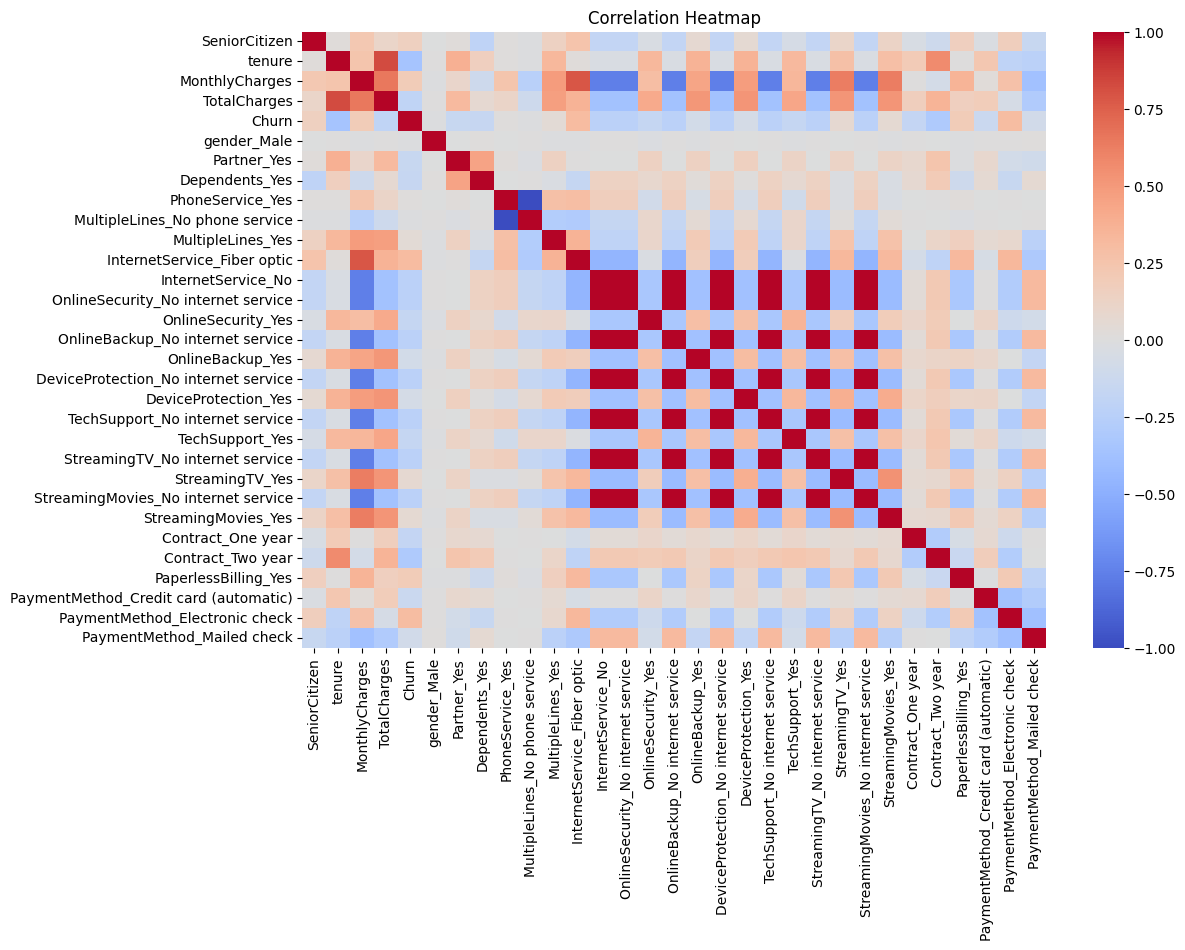

In [7]:
# Correlation plot between features and the target variable "Churn"
plt.figure(figsize=(12,8))
sns.heatmap(telecom_cust_dummies.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

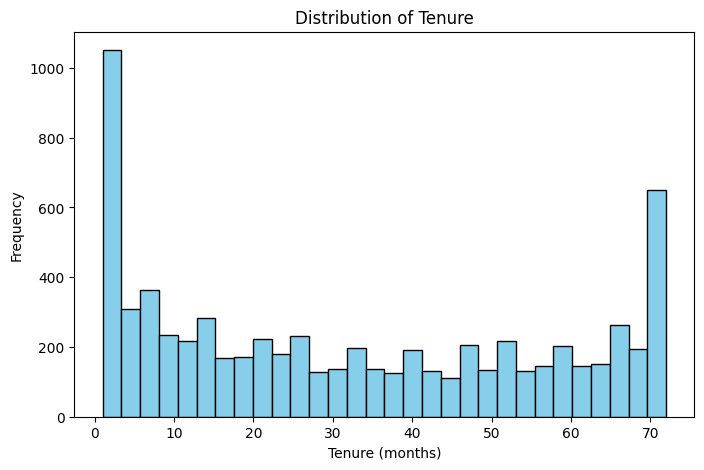

In [8]:
# Histogram of the "tenure" column
plt.figure(figsize=(8, 5))
plt.hist(data['tenure'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Tenure') 
plt.xlabel('Tenure (months)')
plt.ylabel('Frequency')
plt.show()

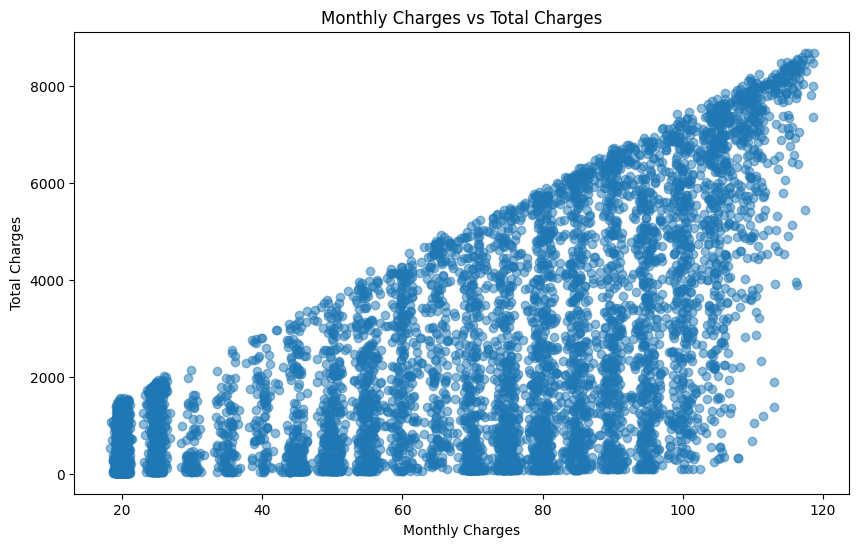

In [9]:
# Scatter plot of "MonthlyCharges" vs. "TotalCharges"
plt.figure(figsize=(10, 6))
plt.scatter(data['MonthlyCharges'], data['TotalCharges'], alpha=0.5)
plt.title('Monthly Charges vs Total Charges')
plt.xlabel('Monthly Charges')       
plt.ylabel('Total Charges')
plt.show()

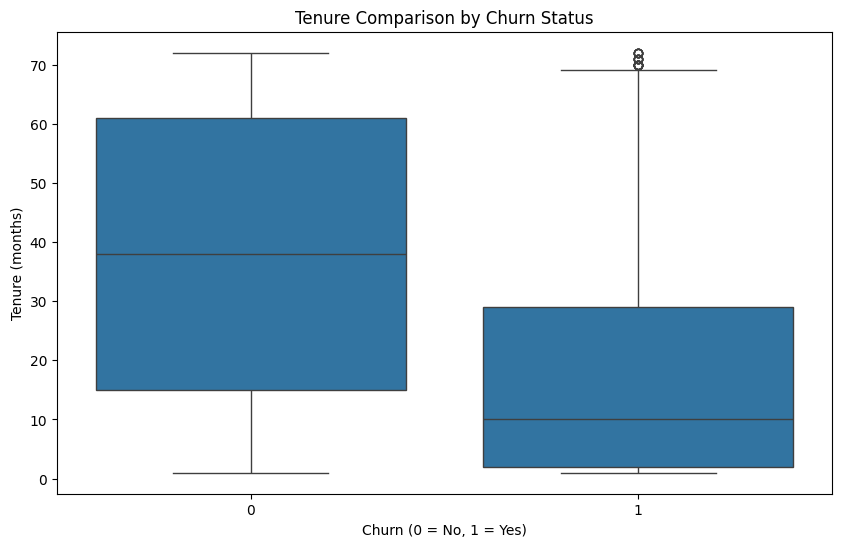

In [10]:
# Box plot to compare "tenure" for churned and non-churned customers
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=data)
plt.title('Tenure Comparison by Churn Status')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Tenure (months)')
plt.show()

**Insights:**  
- Churn negatively correlated with tenure: shorter-tenure customers more likely to churn.  
- Most customers have short tenure.  
- Boxplot shows clear tenure differences between churners and non-churners.

-----------------------------------------------------------------------
## Preparing Data for Machine Learning

- Scale all the variables to a range of 0 to 1 using min-max scaling.
- Split the dataset into training and test set with a test size of 25%.

In [11]:
# Split features and target
X = telecom_cust_dummies.drop('Churn', axis=1)
y = telecom_cust_dummies['Churn']

# Split the dataset into training and test set with a test size of 25%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Scale features using MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


__________________________________________________________________________
## Logistic Regression Model

- Train a logistic regression model on the training data.
- Make predictions on the test data.
- Calculate and print the accuracy score of the logistic regression model.

In [12]:
# Train a logistic regression model on the training data
logistic_model = LogisticRegression(max_iter=1000, random_state=42)  
logistic_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
# Predict on the test data
log_preds = logistic_model.predict(X_test) 

Accuracy: 0.7912
Precision: 0.6188
Recall: 0.5175


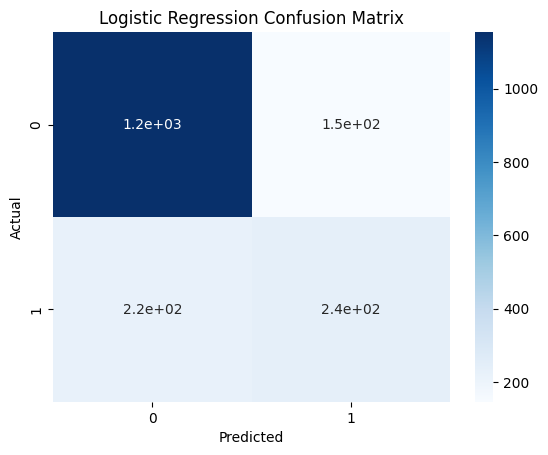

In [14]:
# Calculate the accuracy score of the logistic regression model
log_acc = accuracy_score(y_test, log_preds)
log_cm = confusion_matrix(y_test, log_preds)
log_precision = precision_score(y_test, log_preds)
log_recall = recall_score(y_test, log_preds)

print(f"Accuracy: {log_acc:.4f}")
print(f"Precision: {log_precision:.4f}")
print(f"Recall: {log_recall:.4f}")

sns.heatmap(log_cm, annot=True, cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

__________________________________________________________
## Random Forest Model

- Create a random forest classifier:
  - The number of decision trees in the forest should be 2 000.

  
  - Enable out-of-bag (OOB) error estimation. OOB estimation offers a valuable estimate of model accuracy without requiring a separate validation set.
  - The maximum number of features considered for splitting should be set to “sqrt”. The max_features parameter controls this and influences model diversity. 
  - The maximum number of leaf nodes in each tree should be 50. The parameter is regulated by max_leaf_nodes, and constraints tree complexity.
  - Activate bootstrapping.

Accuracy: 0.7935
OOB Error: 0.1928
Precision: 0.6480
Recall: 0.4541


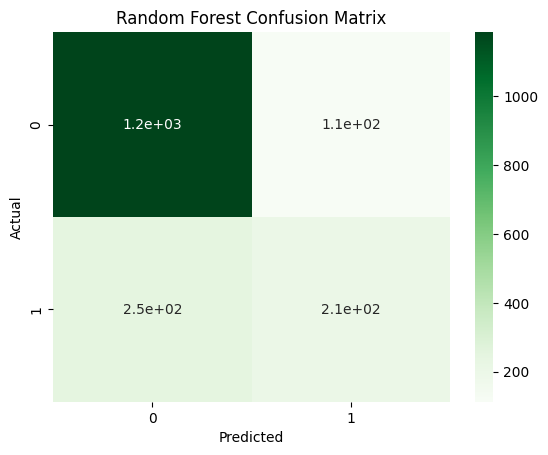

In [15]:
# Create a random forest classifier model
rf_model = RandomForestClassifier(
    # Hyperparameters for the Random Forest model
    n_estimators=2000,
    oob_score=True,
    max_features='sqrt',
    max_leaf_nodes=50,
    bootstrap=True,
    random_state=42
)

#Fit the model on the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test data
rf_preds = rf_model.predict(X_test)

# Calculate accuracy and out-of-bag error(OOB error)
rf_acc = accuracy_score(y_test, rf_preds)
rf_cm = confusion_matrix(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds)
rf_recall = recall_score(y_test, rf_preds)
oob_error = 1 - rf_model.oob_score_

print(f"Accuracy: {rf_acc:.4f}")
print(f"OOB Error: {oob_error:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")

sns.heatmap(rf_cm, annot=True, cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


**Insights:**

- The OOB Error ≈ 0.20, this means the model misclassifies about 20% of unseen samples.

- The small difference between the OOB error and test set error is a good sign that the model generalises well.

____________________________________________________________________
## Enhanced model evaluation

- Confusion matrix for both the logistic regression and random forest models.
- Compute the precision and recall scores for each model.
- Discuss what the confusion matrix reveals about the model's performance. 
- Compare the logistic regression and random forest models. 


Logistic Regression Confusion Matrix:
[[1154  146]
 [ 221  237]]
Precision: 0.6188
Recall: 0.5175


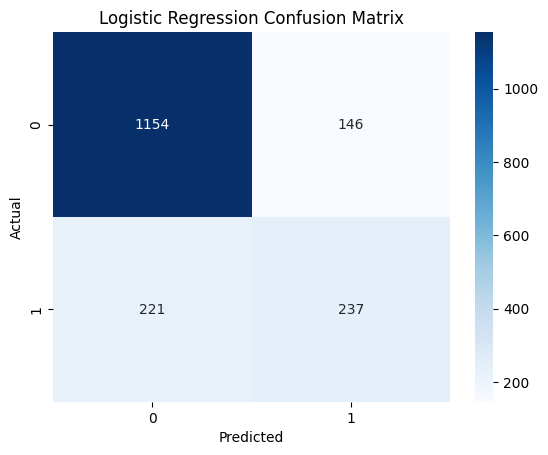


Random Forest Confusion Matrix:
[[1187  113]
 [ 250  208]]
Precision: 0.6480
Recall: 0.4541


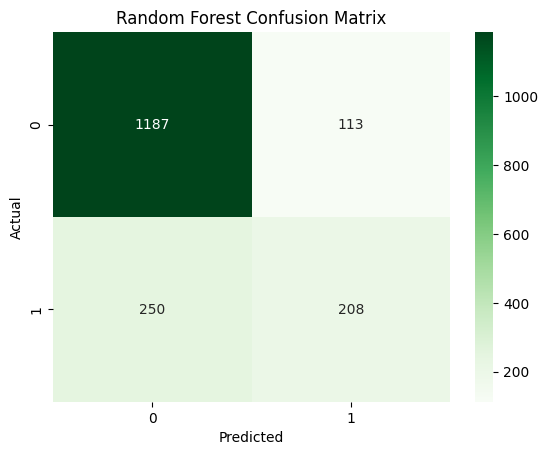

In [16]:
# Calculate the confusion matrix for the logistic regression model
log_cm = confusion_matrix(y_test, log_preds)
log_precision = precision_score(y_test, log_preds)
log_recall = recall_score(y_test, log_preds)

print("\nLogistic Regression Confusion Matrix:")
print(log_cm)
print(f"Precision: {log_precision:.4f}")
print(f"Recall: {log_recall:.4f}")

sns.heatmap(log_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Calculate the confusion matrix for the random forest model
rf_cm = confusion_matrix(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds)
rf_recall = recall_score(y_test, rf_preds)

print("\nRandom Forest Confusion Matrix:")
print(rf_cm)
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


**Analysis:**  
- Although the Random Forest model achieves a slightly higher accuracy, it has more false negatives than Logistic Regression. This is reflected in the lower recall score (0.4541 vs 0.5175), meaning Logistic Regression is better at identifying customers who actually churn.